# RAG Evaluation with Ragas & DeepEval

A hands-on notebook comparing **OpenAI** and **Anthropic** answer quality on the SQuAD v2 dataset using two modern LLM evaluation frameworks.

**Dataset**: [SQuAD v2](https://rajpurkar.github.io/SQuAD-explorer/) — reading-comprehension QA with context passages and ground-truth answers. Each sample has exactly what a RAG pipeline produces: a retrieved context chunk, a generated answer, and a reference answer.

**Models compared**
- Generator: `gpt-4o-mini` vs `claude-haiku-4-5` (fast + cheap, good for benchmarking)
- Judge LLM: configurable via `OPENAI_JUDGE_MODEL` (default `gpt-4o-mini`). OpenAI **gpt-5.x dot** judges (e.g. `gpt-5.4-mini`) need `max_completion_tokens` instead of `max_tokens`; the notebook patches Ragas for that before creating the judge.

**Install**: `pip install -r requirements.txt`

## Package Capabilities Overview

Both packages go far beyond simple groundedness/faithfulness checks.

### Ragas — RAG-specific metrics

| Metric | What it measures | Needs ground truth? |
|--------|-----------------|---------------------|
| **Faithfulness** | Every claim in the answer is supported by the retrieved context | No |
| **ContextPrecision** | Retrieved chunks are ranked with the most relevant ones first | Yes |
| **LLMContextRecall** | The retrieved context contains all info needed to answer correctly | Yes |
| **FactualCorrectness** | Facts in the answer match the reference (precision + recall of claims) | Yes |
| **AnswerRelevancy** | The answer directly addresses the question (not off-topic) | No |
| **NoiseSensitivity** | Answer stability when irrelevant chunks are added to context | Yes |
| **SemanticSimilarity** | Embedding similarity between answer and reference | Yes |
| **AspectCritic** | Pass/fail on a natural-language aspect (e.g., "Is the answer polite?") | No |
| **SimpleCriteriaScore** | 0–1 score on a custom natural-language criterion | No |
| Agent metrics | ToolCallAccuracy, AgentGoalAccuracy for agentic pipelines | Varies |

### DeepEval — General-purpose LLM testing

| Metric | What it measures | Needs ground truth? |
|--------|-----------------|---------------------|
| **FaithfulnessMetric** | Answer is grounded in the retrieved context | No |
| **AnswerRelevancyMetric** | Answer addresses the user's question | No |
| **ContextualRelevancyMetric** | Each retrieved chunk is relevant to the query | No |
| **ContextualPrecisionMetric** | Retrieved chunks are ranked with relevant ones first | Yes |
| **ContextualRecallMetric** | Retrieved context covers the expected answer | Yes |
| **HallucinationMetric** | Answer contains fabricated facts not in the context | No |
| **GEval** | Flexible rubric-based evaluation using any criteria you define | Varies |
| **SummarizationMetric** | Quality of document summaries | No |
| **BiasMetric** | Detects gender, racial, or political bias | No |
| **ToxicityMetric** | Detects harmful or offensive content | No |
| Agent metrics | ToolCorrectnessMetric, TaskCompletionMetric for agents | Varies |

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv

# Must be set BEFORE importing deepeval, or deepeval prompts you to log in
os.environ["DEEPEVAL_TELEMETRY_OPT_OUT"] = "YES"

for _root in [Path.cwd(), *Path.cwd().parents]:
    _env = _root / ".env"
    if _env.is_file():
        load_dotenv(_env)
        break

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "").strip()
ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "").strip()
assert OPENAI_API_KEY, "OPENAI_API_KEY missing from .env"
assert ANTHROPIC_API_KEY, "ANTHROPIC_API_KEY missing from .env"

OPENAI_GEN_MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o-mini")
ANTHROPIC_GEN_MODEL = "claude-haiku-4-5-20251001"
JUDGE_MODEL = os.environ.get("OPENAI_JUDGE_MODEL", "gpt-4o-mini")
N_SAMPLES = 15  # small enough to be cheap, big enough to be meaningful


def _agg_mean_score(series: pd.Series) -> float:
    """Column mean; NaN if there are no finite values (e.g. all judge calls failed)."""
    v = pd.to_numeric(series, errors="coerce")
    if v.isna().all():
        return float("nan")
    return float(v.mean(skipna=True))


def _round_metric(x: float) -> float:
    return round(x, 3) if np.isfinite(x) else float("nan")


def _winner_two_column(openai_val: float, anthropic_val: float) -> str:
    o_ok = np.isfinite(openai_val)
    a_ok = np.isfinite(anthropic_val)
    if not o_ok and not a_ok:
        return "—"
    if not o_ok:
        return "Anthropic"
    if not a_ok:
        return "OpenAI"
    return "OpenAI" if openai_val >= anthropic_val else "Anthropic"


print(f"OpenAI generator:    {OPENAI_GEN_MODEL}")
print(f"Anthropic generator: {ANTHROPIC_GEN_MODEL}")
print(f"Judge model:         {JUDGE_MODEL}")
print(f"N samples:           {N_SAMPLES}")

OpenAI generator:    gpt-4o-mini
Anthropic generator: claude-haiku-4-5-20251001
Judge model:         gpt-5.4-mini
N samples:           15


### Initialize API Clients

> **Key Ragas gotcha**: `evaluate()` injects a judge LLM and embeddings into metrics that need them. Use `llm_factory` with your OpenAI client for the judge. For `AnswerRelevancy`, embeddings must expose LangChain-style `embed_query` / `embed_documents` (e.g. `langchain_openai.OpenAIEmbeddings`), not the slim `ragas.embeddings.OpenAIEmbeddings` client wrapper.
>
> **GPT-5 dot releases** (e.g. `gpt-5.4-mini`): Ragas maps `max_tokens` → `max_completion_tokens` only for names it recognizes; minor versions like `5.4` are skipped. The next code cell patches that before building the judge LLM.

In [2]:
from openai import OpenAI
from anthropic import Anthropic
from langchain_openai import OpenAIEmbeddings as LangchainOpenAIEmbeddings
from ragas.llms import base as _ragas_llm_base
from ragas.llms import llm_factory

# Ragas misses gpt-5.MINOR.* (e.g. gpt-5.4-mini): version "5.4" is not int()-parsed, so it still sends max_tokens.
_orig_map_openai = _ragas_llm_base.InstructorLLM._map_openai_params


def _map_openai_params_gpt5dot(_self):
    mapped = _orig_map_openai(_self)
    name = (_self.model or "").lower()
    if name.startswith("gpt-5.") and "max_tokens" in mapped:
        mapped["max_completion_tokens"] = mapped.pop("max_tokens")
        mapped["temperature"] = 1.0
        mapped.pop("top_p", None)
    return mapped


_ragas_llm_base.InstructorLLM._map_openai_params = _map_openai_params_gpt5dot  # type: ignore[method-assign]

# Direct clients — used to generate answers
oai_client = OpenAI(api_key=OPENAI_API_KEY)
ant_client = Anthropic(api_key=ANTHROPIC_API_KEY)

# Ragas judge LLM (works with evaluate() + legacy metrics)
ragas_llm = llm_factory(JUDGE_MODEL, client=oai_client)
# AnswerRelevancy expects LangChain embedding methods (embed_query / embed_documents)
ragas_embeddings = LangchainOpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENAI_API_KEY,
)

print("All clients initialized.")

/Users/larryjin/Documents/Programs/anaconda3/envs/prototype/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All clients initialized.


## Dataset — SQuAD v2

SQuAD v2 is ideal for RAG evaluation because each row contains:
- `context` — the retrieved passage (our "RAG context")
- `question` — the user query
- `answers.text` — ground-truth answer(s)

We filter to **answerable** rows (SQuAD v2 includes unanswerable questions too) and take a small shuffle-stable subset.

In [3]:
from datasets import load_dataset

ds = load_dataset("rajpurkar/squad_v2")
val_ds = ds["validation"]

answerable_val = val_ds.filter(lambda row: bool(row["answers"]["text"]))
subset = answerable_val.shuffle(seed=42).select(range(N_SAMPLES))

print(f"Total answerable validation rows: {len(answerable_val)}")
print(f"Using subset of: {len(subset)} rows")
print("\nSample row:")
subset[0]

Total answerable validation rows: 5928
Using subset of: 15 rows

Sample row:


{'id': '573020f7b2c2fd14005688fa',
 'title': 'Islamism',
 'context': 'Hamas has continued to be a major player in Palestine. From 2000 to 2007 it killed 542 people in 140 suicide bombing or "martyrdom operations". In the January 2006 legislative election—its first foray into the political process—it won the majority of the seats, and in 2007 it drove the PLO out of Gaza. Hamas has been praised by Muslims for driving Israel out of the Gaza Strip, but criticized for failure to achieve its demands in the 2008-9 and 2014 Gaza Wars despite heavy destruction and significant loss of life.',
 'question': 'When did Hamas drive the PLO out of Gaza?',
 'answers': {'text': ['2007', '2007', '2007'],
  'answer_start': [269, 269, 269]}}

## Generate Answers — OpenAI & Anthropic

We use a strict system prompt so the models answer from context only, simulating a RAG generator. This makes faithfulness metrics meaningful — any answer not grounded in the context is a genuine failure.

In [4]:
QA_SYSTEM = (
    "Answer the reading-comprehension question using only the provided passage. "
    "Reply with the shortest correct answer phrase. No preamble, no quotes."
)


def generate_openai(context: str, question: str) -> str:
    resp = oai_client.chat.completions.create(
        model=OPENAI_GEN_MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": QA_SYSTEM},
            {"role": "user", "content": f"Passage:\n{context}\n\nQuestion:\n{question}"},
        ],
    )
    return resp.choices[0].message.content.strip()


def generate_anthropic(context: str, question: str) -> str:
    resp = ant_client.messages.create(
        model=ANTHROPIC_GEN_MODEL,
        system=QA_SYSTEM,
        max_tokens=256,
        messages=[{"role": "user", "content": f"Passage:\n{context}\n\nQuestion:\n{question}"}],
    )
    return resp.content[0].text.strip()

In [5]:
rows = []
print(f"Generating answers for {N_SAMPLES} questions...")
for i, row in enumerate(subset):
    ground_truth = row["answers"]["text"][0]
    oai_ans = generate_openai(row["context"], row["question"])
    time.sleep(0.1)
    ant_ans = generate_anthropic(row["context"], row["question"])
    rows.append({
        "question":         row["question"],
        "context":          row["context"],
        "ground_truth":     ground_truth,
        "openai_answer":    oai_ans,
        "anthropic_answer": ant_ans,
    })
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  [{i + 1}/{N_SAMPLES}] Q: {row['question'][:60]}")
        print(f"          GT:  {ground_truth}")
        print(f"          OAI: {oai_ans}")
        print(f"          ANT: {ant_ans}")

print(f"\nDone — {len(rows)} rows generated.")

Generating answers for 15 questions...
  [1/15] Q: When did Hamas drive the PLO out of Gaza?
          GT:  2007
          OAI: 2007
          ANT: 2007
  [5/15] Q: Contracts must be designed to ensure what?
          GT:  that each side is capable of performing the obligations set out
          OAI: Each side is capable of performing the obligations.
          ANT: that each side is capable of performing the obligations set out
  [10/15] Q: What are the three sources of European Union law?
          GT:  primary law, secondary law and supplementary law
          OAI: Primary law, secondary law, supplementary law.
          ANT: primary law, secondary law and supplementary law
  [15/15] Q: What is restrained with a lever in the top of a boiler?
          GT:  plug valve
          OAI: A plug valve.
          ANT: A plug valve

Done — 15 rows generated.


In [6]:
pd.set_option("display.max_colwidth", 80)
pd.DataFrame([
    {
        "Question":     r["question"][:70],
        "Ground Truth": r["ground_truth"],
        "OpenAI":       r["openai_answer"],
        "Anthropic":    r["anthropic_answer"],
    }
    for r in rows[:5]
])

,Question,Ground Truth,OpenAI,Anthropic
0,When did Hamas drive the PLO out of Gaza?,2007,2007,2007
1,Where can Aeolian sand with a number of dunes be found?,plain Vistula terraces,On the highest terrace.,On the highest terrace of the right side of Warsaw.
2,What do ctenophores have that no other animals have?,colloblasts,Colloblasts,Colloblasts
3,What is the name of the holding company for BSkyB?,Sky plc,Sky plc,Sky plc
4,Contracts must be designed to ensure what?,that each side is capable of performing the obligations set out,Each side is capable of performing the obligations.,that each side is capable of performing the obligations set out


## Ragas Evaluation

Ragas wraps evaluation in an `EvaluationDataset` of `SingleTurnSample` objects. Each sample must contain:

| Field | Maps to (SQuAD) |
|-------|-----------------|
| `user_input` | `question` |
| `retrieved_contexts` | `[context]` (single chunk list) |
| `response` | generated answer |
| `reference` | `answers.text[0]` (single string, not a list) |

**Metrics we'll use** — loaded from `ragas.metrics` (the classes `evaluate()` accepts). The call below passes `llm=` and `embeddings=` so every metric gets the judge model; `AnswerRelevancy` also needs embeddings.

| Metric | Requires embeddings? |
|--------|---------------------|
| `Faithfulness` | No |
| `ContextPrecision` | No |
| `LLMContextRecall` | No |
| `FactualCorrectness` | No |
| `AnswerRelevancy` | **Yes** — generates paraphrase questions and checks cosine similarity |

In [7]:
import warnings

from ragas import EvaluationDataset, evaluate as ragas_evaluate

# evaluate() only accepts legacy Metric subclasses from ragas.metrics, not ragas.metrics.collections
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from ragas.metrics import (
        Faithfulness,
        ContextPrecision,
        LLMContextRecall,
        FactualCorrectness,
        AnswerRelevancy,
    )

ragas_metrics = [
    Faithfulness(),
    ContextPrecision(),
    LLMContextRecall(),
    FactualCorrectness(),
    AnswerRelevancy(),
]


def build_ragas_dataset(rows: list[dict], answer_key: str) -> EvaluationDataset:
    return EvaluationDataset.from_list([
        {
            "user_input":         r["question"],
            "retrieved_contexts": [r["context"]],   # list of context chunks
            "response":           r[answer_key],
            "reference":          r["ground_truth"],  # single string, NOT a list
        }
        for r in rows
    ])


print("Ragas metrics ready:", [type(m).__name__ for m in ragas_metrics])

Ragas metrics ready: ['Faithfulness', 'ContextPrecision', 'LLMContextRecall', 'FactualCorrectness', 'AnswerRelevancy']


In [8]:
print("Running Ragas on OpenAI answers...")
oai_ragas_ds = build_ragas_dataset(rows, "openai_answer")
oai_ragas_result = ragas_evaluate(
    oai_ragas_ds, metrics=ragas_metrics, llm=ragas_llm, embeddings=ragas_embeddings
)

print("\nRunning Ragas on Anthropic answers...")
ant_ragas_ds = build_ragas_dataset(rows, "anthropic_answer")
ant_ragas_result = ragas_evaluate(
    ant_ragas_ds, metrics=ragas_metrics, llm=ragas_llm, embeddings=ragas_embeddings
)

print("\nDone!")

Running Ragas on OpenAI answers...


Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 


Running Ragas on Anthropic answers...


Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 


Done!


In [9]:
oai_ragas_df = oai_ragas_result.to_pandas()
ant_ragas_df = ant_ragas_result.to_pandas()

# Identify numeric metric columns (exclude sample-level text fields)
_skip = {"user_input", "retrieved_contexts", "response", "reference", "id"}
ragas_metric_cols = [c for c in oai_ragas_df.columns if c not in _skip]

ragas_comparison = pd.DataFrame({
    "OpenAI":    {col: _round_metric(_agg_mean_score(oai_ragas_df[col])) for col in ragas_metric_cols},
    "Anthropic": {col: _round_metric(_agg_mean_score(ant_ragas_df[col])) for col in ragas_metric_cols},
})
ragas_comparison["Winner"] = [
    _winner_two_column(o, a) for o, a in zip(ragas_comparison["OpenAI"], ragas_comparison["Anthropic"])
]
ragas_comparison.index.name = "Metric"
print("Ragas comparison (mean across", N_SAMPLES, "samples)")
ragas_comparison

Ragas comparison (mean across 15 samples)


,OpenAI,Anthropic,Winner
Metric,,,
faithfulness,1.000,0.833,OpenAI
context_precision,1.000,1.000,OpenAI
context_recall,1.000,1.000,OpenAI
factual_correctness(mode=f1),0.500,1.000,Anthropic
answer_relevancy,0.365,0.297,OpenAI


## DeepEval Evaluation

DeepEval uses `LLMTestCase` objects. Key fields:

| Field | Purpose | Maps to (SQuAD) |
|-------|---------|------------------|
| `input` | User's question | `question` |
| `actual_output` | LLM's generated answer | generated answer |
| `expected_output` | Ground truth (for precision/recall) | `answers.text[0]` |
| `retrieval_context` | Chunks that were retrieved | `[context]` |
| `context` | Ideal knowledge (for HallucinationMetric only) | `[context]` |

> **`context` vs `retrieval_context`**: `HallucinationMetric` uses `context` (the golden knowledge base). All other RAG metrics (`Faithfulness`, `ContextualPrecision`, etc.) use `retrieval_context`. In our case they're the same SQuAD passage.

**Metrics we'll use**:
- `FaithfulnessMetric` — same concept as Ragas Faithfulness, good for cross-framework comparison
- `AnswerRelevancyMetric` — is the answer on-topic?
- `ContextualPrecisionMetric` — are the retrieved chunks relevant?
- `ContextualRecallMetric` — does context cover the expected answer?
- `HallucinationMetric` — does the answer fabricate facts?
- `GEval(Conciseness)` — custom rubric: is the answer concise?

In [10]:
from deepeval.metrics import (
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    HallucinationMetric,
    GEval,
)
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

_threshold = 0.5
_model = JUDGE_MODEL

deepeval_metrics = [
    FaithfulnessMetric(model=_model, threshold=_threshold),
    AnswerRelevancyMetric(model=_model, threshold=_threshold),
    ContextualPrecisionMetric(model=_model, threshold=_threshold),
    ContextualRecallMetric(model=_model, threshold=_threshold),
    HallucinationMetric(model=_model, threshold=_threshold),
    GEval(
        name="Conciseness",
        criteria=(
            "Evaluate whether the answer is concise. "
            "A concise answer gives the necessary information without verbosity, repetition, or filler phrases."
        ),
        evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
        model=_model,
        threshold=_threshold,
    ),
]

print("DeepEval metrics:", [type(m).__name__ if not isinstance(m, GEval) else f"GEval({m.name})" for m in deepeval_metrics])

DeepEval metrics: ['FaithfulnessMetric', 'AnswerRelevancyMetric', 'ContextualPrecisionMetric', 'ContextualRecallMetric', 'HallucinationMetric', 'GEval(Conciseness)']


/var/folders/vd/69kmbq6s0s331vf09zfxgmh40000gn/T/ipykernel_65812/2766483864.py:9: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams


In [11]:
def build_deepeval_cases(rows: list[dict], answer_key: str) -> list[LLMTestCase]:
    return [
        LLMTestCase(
            input=r["question"],
            actual_output=r[answer_key],
            expected_output=r["ground_truth"],
            retrieval_context=[r["context"]],  # for Faithfulness, Contextual* metrics
            context=[r["context"]],            # for HallucinationMetric
        )
        for r in rows
    ]


def run_deepeval(test_cases: list[LLMTestCase], metrics: list) -> dict[str, float]:
    """Run each metric on each test case; return per-metric mean score."""
    scores: dict[str, list[float]] = {}
    for m in metrics:
        name = m.name if isinstance(m, GEval) else type(m).__name__
        scores[name] = []

    for i, tc in enumerate(test_cases):
        for m in metrics:
            name = m.name if isinstance(m, GEval) else type(m).__name__
            try:
                m.measure(tc)
                scores[name].append(m.score)
            except Exception as e:
                print(f"  Warning [{name}] case {i}: {e}")
        if (i + 1) % 5 == 0:
            print(f"  [{i + 1}/{len(test_cases)}] done")

    return {k: round(float(np.mean(v)), 3) if v else 0.0 for k, v in scores.items()}

In [12]:
print("Running DeepEval on OpenAI answers...")
oai_deepeval_cases = build_deepeval_cases(rows, "openai_answer")
oai_deepeval_scores = run_deepeval(oai_deepeval_cases, deepeval_metrics)

print("\nRunning DeepEval on Anthropic answers...")
ant_deepeval_cases = build_deepeval_cases(rows, "anthropic_answer")
ant_deepeval_scores = run_deepeval(ant_deepeval_cases, deepeval_metrics)

print("\nDone!")

/Users/larryjin/Documents/Programs/anaconda3/envs/prototype/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Running DeepEval on OpenAI answers...


  [5/15] done


  [10/15] done


  [15/15] done

Running DeepEval on Anthropic answers...


  [5/15] done


  [10/15] done


  [15/15] done

Done!


In [13]:
deepeval_comparison = pd.DataFrame({
    "OpenAI":    oai_deepeval_scores,
    "Anthropic": ant_deepeval_scores,
}).apply(pd.to_numeric, errors="coerce")
deepeval_comparison["Winner"] = [
    _winner_two_column(o, a) for o, a in zip(deepeval_comparison["OpenAI"], deepeval_comparison["Anthropic"])
]
deepeval_comparison.index.name = "Metric"
print("DeepEval comparison (mean across", N_SAMPLES, "samples)")
deepeval_comparison

DeepEval comparison (mean across 15 samples)


,OpenAI,Anthropic,Winner
Metric,,,
FaithfulnessMetric,1.000,0.933,OpenAI
AnswerRelevancyMetric,0.933,0.800,OpenAI
ContextualPrecisionMetric,1.000,1.000,OpenAI
ContextualRecallMetric,1.000,0.933,OpenAI
HallucinationMetric,0.200,0.200,OpenAI
Conciseness,0.927,0.880,OpenAI


## Final Comparison — Side by Side

Combining both frameworks lets us see whether they agree: if Ragas and DeepEval both say Anthropic is more faithful, that's a stronger signal than one framework alone.

In [14]:
# Shared metric names that appear in both frameworks (faithfulness + answer relevancy)
ragas_comp = ragas_comparison[["OpenAI", "Anthropic"]].copy()
ragas_comp.index = [f"Ragas/{m}" for m in ragas_comp.index]

deepeval_comp = deepeval_comparison[["OpenAI", "Anthropic"]].copy()
deepeval_comp.index = [f"DeepEval/{m}" for m in deepeval_comp.index]

all_metrics = pd.concat([ragas_comp, deepeval_comp])
all_metrics["OpenAI wins"] = all_metrics["OpenAI"] > all_metrics["Anthropic"]
all_metrics["Diff (OAI - ANT)"] = (all_metrics["OpenAI"] - all_metrics["Anthropic"]).round(3)

print(f"OpenAI wins:    {all_metrics['OpenAI wins'].sum()} / {len(all_metrics)}")
print(f"Anthropic wins: {(~all_metrics['OpenAI wins']).sum()} / {len(all_metrics)}")
all_metrics

OpenAI wins:    6 / 11
Anthropic wins: 5 / 11


,OpenAI,Anthropic,OpenAI wins,Diff (OAI - ANT)
Ragas/faithfulness,1.000,0.833,True,0.167
Ragas/context_precision,1.000,1.000,False,0.000
Ragas/context_recall,1.000,1.000,False,0.000
Ragas/factual_correctness(mode=f1),0.500,1.000,False,-0.500
Ragas/answer_relevancy,0.365,0.297,True,0.068
DeepEval/FaithfulnessMetric,1.000,0.933,True,0.067
DeepEval/AnswerRelevancyMetric,0.933,0.800,True,0.133
DeepEval/ContextualPrecisionMetric,1.000,1.000,False,0.000
DeepEval/ContextualRecallMetric,1.000,0.933,True,0.067
DeepEval/HallucinationMetric,0.200,0.200,False,0.000


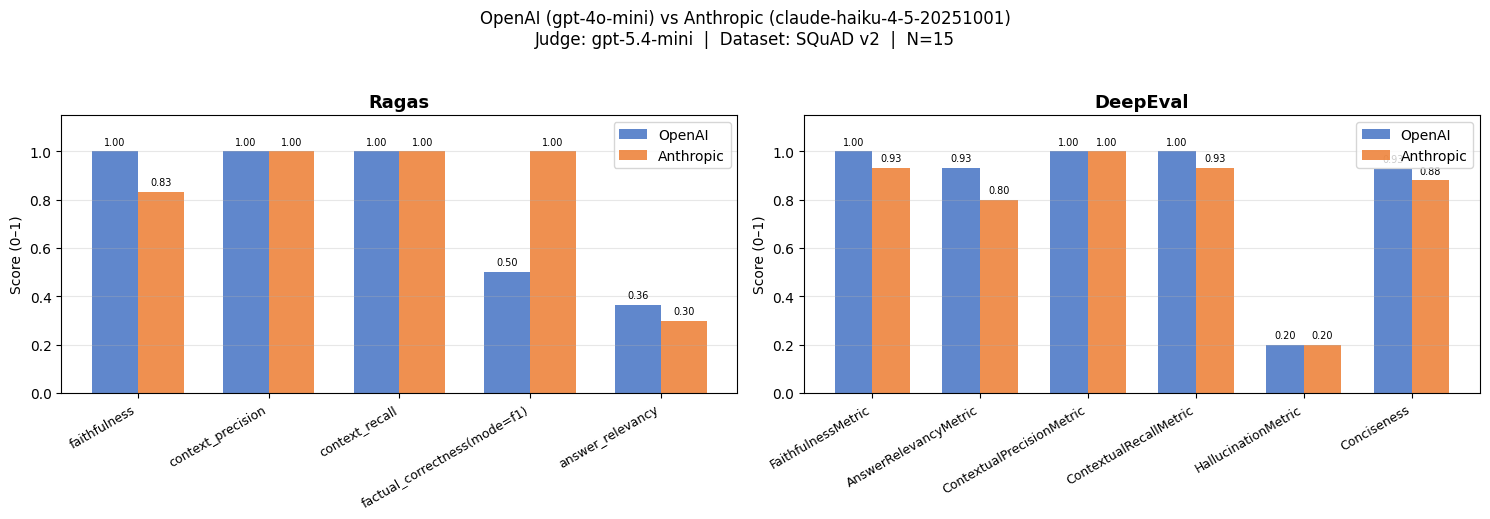

Chart saved to model_comparison.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
_blue, _orange = "#4472C4", "#ED7D31"

for ax, (df, title) in zip(axes, [
    (ragas_comparison[["OpenAI", "Anthropic"]], "Ragas"),
    (deepeval_comparison[["OpenAI", "Anthropic"]], "DeepEval"),
]):
    plot_df = df.apply(pd.to_numeric, errors="coerce")
    x = np.arange(len(plot_df))
    w = 0.35
    o = plot_df["OpenAI"].to_numpy(dtype=float)
    a = plot_df["Anthropic"].to_numpy(dtype=float)
    ho = np.where(np.isfinite(o), o, 0.0)
    ha = np.where(np.isfinite(a), a, 0.0)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Score (0–1)")
    ax.set_ylim(0, 1.15)

    if not (np.isfinite(o).any() or np.isfinite(a).any()):
        ax.text(0.5, 0.55, "No finite scores\n(fix judge LLM / API errors)", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        continue

    ax.bar(x - w / 2, ho, w, label="OpenAI", color=_blue, alpha=0.85)
    ax.bar(x + w / 2, ha, w, label="Anthropic", color=_orange, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=30, ha="right", fontsize=9)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    for xi, vo, va in zip(x, o, a):
        if np.isfinite(vo):
            ax.text(xi - w / 2, vo + 0.02, f"{vo:.2f}", ha="center", va="bottom", fontsize=7)
        if np.isfinite(va):
            ax.text(xi + w / 2, va + 0.02, f"{va:.2f}", ha="center", va="bottom", fontsize=7)

plt.suptitle(
    f"OpenAI ({OPENAI_GEN_MODEL}) vs Anthropic ({ANTHROPIC_GEN_MODEL})\n"
    f"Judge: {JUDGE_MODEL}  |  Dataset: SQuAD v2  |  N={N_SAMPLES}",
    y=1.03, fontsize=12
)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to model_comparison.png")

## Example: a custom rubric with `GEval`

[`GEval`](https://docs.confident-ai.com/docs/metrics-llm-evals) scores outputs against **criteria you write in plain language**. The main DeepEval block above already includes a small `GEval` (conciseness). Here is a **second, self-contained example**: a rubric that judges whether the model answer **matches the meaning of the SQuAD gold answer** (paraphrase and formatting differences are fine; contradictions or missing key facts score lower).

We pass **`expected_output`** so the judge can compare to the reference. Run this after the cells that define `rows` and `build_deepeval_cases` (or after the DeepEval runs that build `oai_deepeval_cases` / `ant_deepeval_cases`).

In [16]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCaseParams

# Standalone rubric — not part of deepeval_metrics above
reference_agreement_geval = GEval(
    name="Reference agreement",
    criteria=(
        "You are evaluating reading-comprehension answers. "
        "Given the question, the model's answer, and the official (gold) reference answer, "
        "score how well the model answer captures the same meaning as the reference. "
        "Paraphrases, minor wording, and harmless punctuation/capitalization differences are fine. "
        "Penalize answers that omit critical facts, add contradictions, hedge incorrectly, "
        "or address a different question. "
        "Respond with a single score from 0 (poor agreement) to 1 (excellent agreement)."
    ),
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    model=JUDGE_MODEL,
    threshold=0.5,
)


def geval_scores_per_case(cases: list, metric: GEval) -> list[float]:
    scores: list[float] = []
    for i, tc in enumerate(cases):
        metric.measure(tc)
        scores.append(metric.score)
        if (i + 1) % 5 == 0 or i == 0:
            print(f"  [{i + 1}/{len(cases)}] {metric.name}: last score = {metric.score:.3f}")
    return scores


try:
    _ = oai_deepeval_cases, ant_deepeval_cases
except NameError:
    oai_deepeval_cases = build_deepeval_cases(rows, "openai_answer")
    ant_deepeval_cases = build_deepeval_cases(rows, "anthropic_answer")

print("GEval: Reference agreement — OpenAI answers")
oai_ref_agree = geval_scores_per_case(oai_deepeval_cases, reference_agreement_geval)

print("\nGEval: Reference agreement — Anthropic answers")
ant_ref_agree = geval_scores_per_case(ant_deepeval_cases, reference_agreement_geval)

custom_geval_summary = pd.DataFrame({
    "OpenAI_mean":    [round(float(np.mean(oai_ref_agree)), 3)],
    "Anthropic_mean": [round(float(np.mean(ant_ref_agree)), 3)],
}, index=["Reference agreement (GEval)"])
print("\nMean scores across", N_SAMPLES, "samples:")
custom_geval_summary

preview_n = min(5, len(rows))
custom_geval_by_row = pd.DataFrame({
    "Question (truncated)": [r["question"][:55] + ("…" if len(r["question"]) > 55 else "") for r in rows[:preview_n]],
    "Gold (truncated)":     [r["ground_truth"][:40] + ("…" if len(r["ground_truth"]) > 40 else "") for r in rows[:preview_n]],
    "OpenAI score":         oai_ref_agree[:preview_n],
    "Anthropic score":      ant_ref_agree[:preview_n],
})
print(f"\nFirst {preview_n} rows (per-example scores):")
custom_geval_by_row

/Users/larryjin/Documents/Programs/anaconda3/envs/prototype/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/var/folders/vd/69kmbq6s0s331vf09zfxgmh40000gn/T/ipykernel_65812/4120481973.py:2: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCaseParams


GEval: Reference agreement — OpenAI answers


  [1/15] Reference agreement: last score = 1.000


  [5/15] Reference agreement: last score = 0.900


...

  [1/15] Reference agreement: last score = 1.000


  [5/15] Reference agreement: last score = 1.000


  [10/15] Reference agreement: last score = 1.000


  [15/15] Reference agreement: last score = 1.000

Mean scores across 15 samples:

First 5 rows (per-example scores):


,Question (truncated),Gold (truncated),OpenAI score,Anthropic score
0,When did Hamas drive the PLO out of Gaza?,2007,1.0,1.0
1,Where can Aeolian sand with a number of dunes be found?,plain Vistula terraces,0.0,0.2
2,What do ctenophores have that no other animals have?,colloblasts,1.0,1.0
3,What is the name of the holding company for BSkyB?,Sky plc,1.0,1.0
4,Contracts must be designed to ensure what?,that each side is capable of performing …,0.9,1.0


## Key Takeaways

### When to use Ragas
- **RAG pipeline–specific**: Ragas was built specifically for RAG evaluation. Use it when you want metrics that explicitly reason about the retrieval step (`ContextPrecision`, `LLMContextRecall`).
- **FactualCorrectness**: Ragas decomposes answers into atomic claims and checks each against the reference — more fine-grained than simple string matching.
- **Explicit setup for `evaluate()`**: Pass the judge via `llm_factory` and use LangChain `OpenAIEmbeddings` for `AnswerRelevancy`. (`ragas.evaluate` only accepts legacy `ragas.metrics.Metric` instances; `ragas.metrics.collections` targets newer APIs.)

### When to use DeepEval
- **Broader coverage**: DeepEval covers safety (bias, toxicity), summarization, agents, and custom rubrics (`GEval`) in a single framework.
- **`HallucinationMetric`**: Unlike Ragas Faithfulness (claims must be entailed by context), DeepEval's Hallucination detects contradictions — useful when you want to flag outputs that actively state something false.
- **`GEval`**: Define any evaluation criterion in plain English — e.g., conciseness, politeness, domain-specific compliance.

### Cross-framework agreement
- When both Ragas and DeepEval agree on a winner for a metric (e.g., both say Anthropic is more faithful), that's a strong signal.
- Disagreements usually come from different internal prompts/rubrics for the same concept — comparing them side-by-side is a good sanity check.

### Practical tips
- **Cost**: Each metric calls an LLM. With 5 Ragas + 6 DeepEval metrics on 15 samples, expect ~150–200 LLM calls for evaluation alone.
- **Sampling**: 15–30 samples is enough for exploratory work; 100+ for production decisions.
- **Judge bias**: Using the same judge model for both generators keeps comparisons fair, but check if the judge has a known preference for its own outputs.